In [1]:
# load the essential libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [23]:
import warnings 
warnings.filterwarnings('ignore')

In [9]:
# load the data 
df= pd.read_csv('samplesuperstore.csv', encoding= 'Latin-1')

# display the first 5 rows of the data 
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
# chech the columns we have
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [11]:
# check the shape of the data 
df.shape

(9994, 21)

In [ ]:
# let's check the data types of the columns 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [13]:
# check for missing or duplicates values 
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [24]:
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


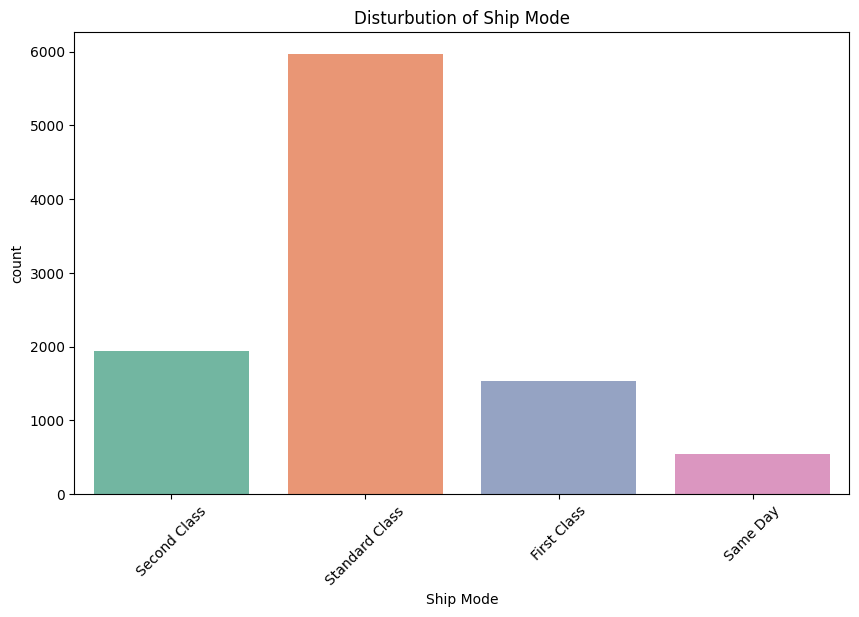

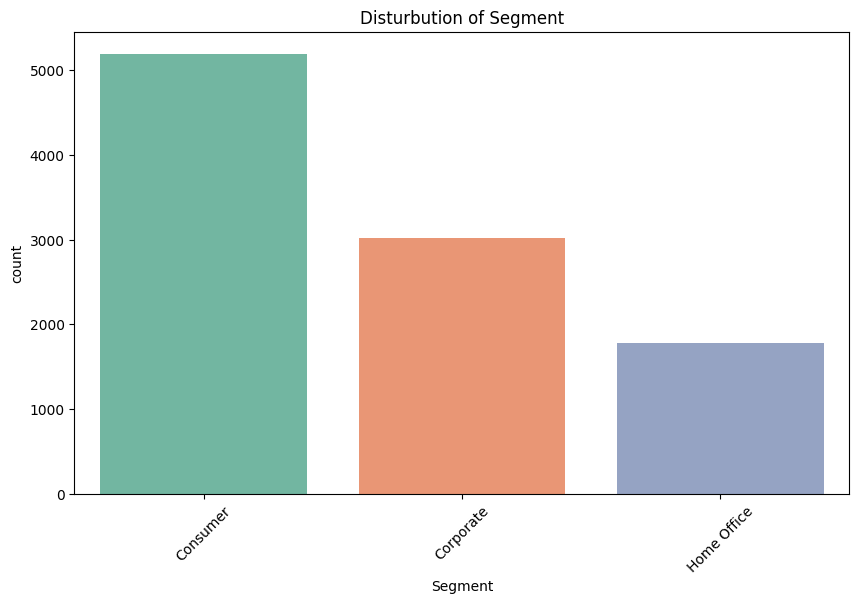

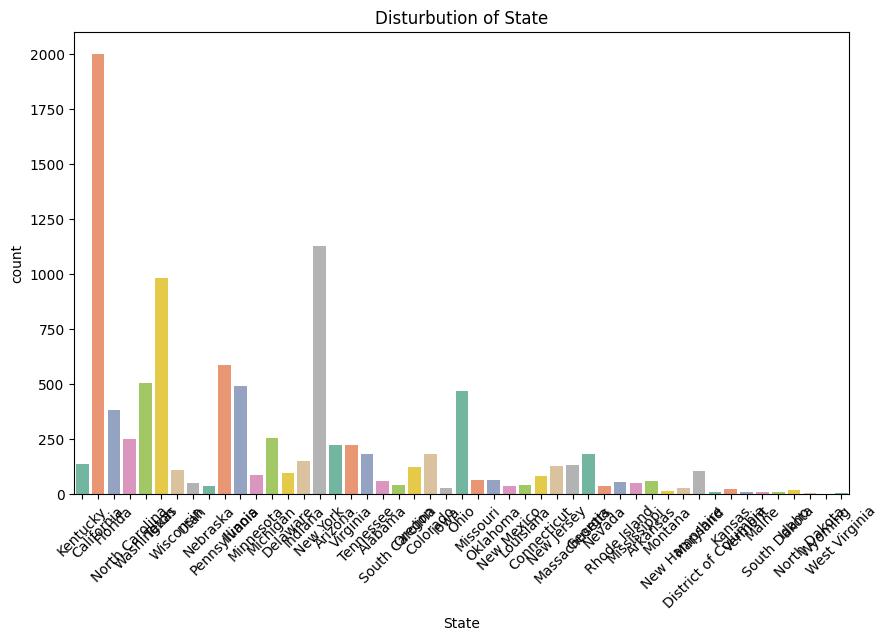

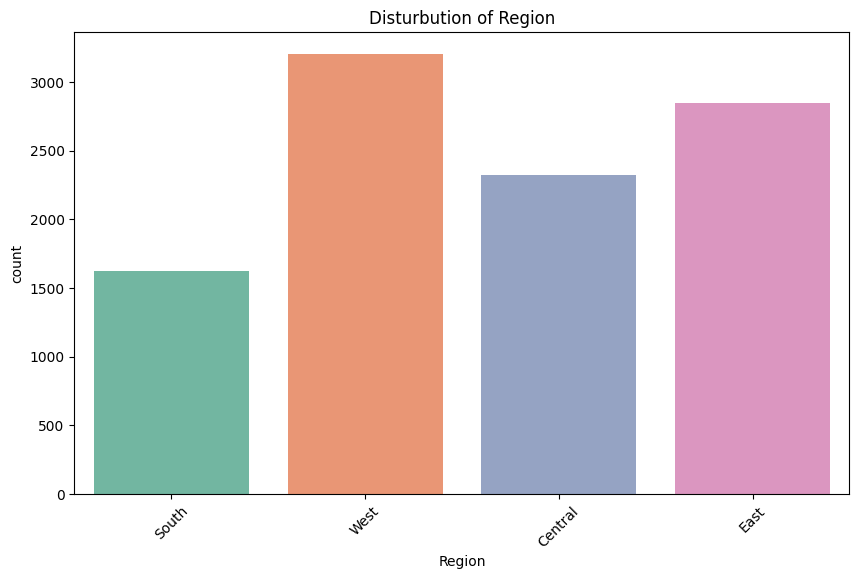

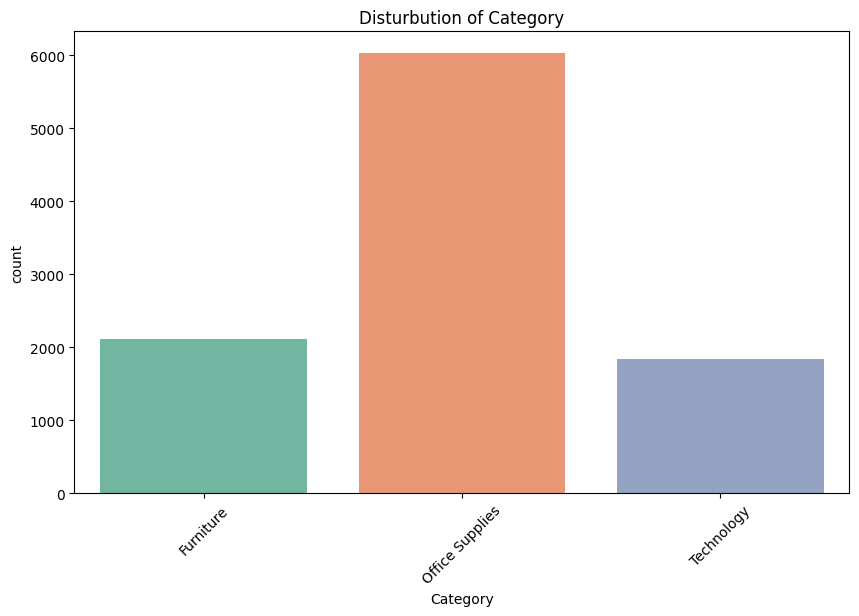

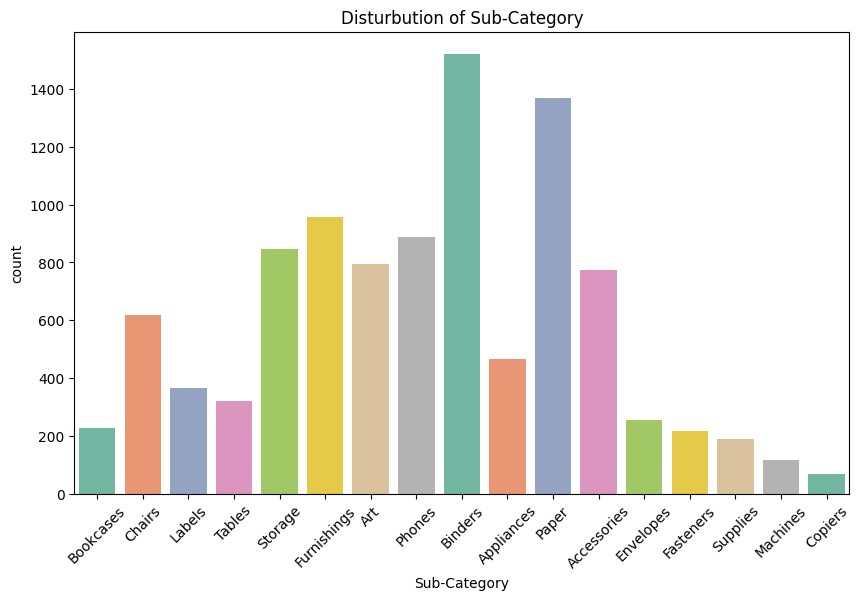

In [32]:
categorical_cols=['Ship Mode', 'Segment','State', 'Region','Category', 'Sub-Category']
for col in categorical_cols:
    plt.figure(figsize=[10,6])
    sns.countplot(x=col , data=df, palette='Set2', color='steelblue')
    plt.title(f"Disturbution of {col}")
    plt.xticks(rotation=45)



In [41]:
# disturbution of sales and profit based on the discount 
df.groupby('Discount')[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending=False)

,Sales,Profit
Discount,,
0.10,578.397351,96.055074
0.00,226.742074,66.900292
0.15,529.971567,27.288298
0.20,209.076940,24.702572
0.60,48.150000,-43.077212
0.30,454.742974,-45.679636
0.32,536.794770,-88.560656
0.70,97.177708,-95.874060
0.80,56.545853,-101.796797


Text(0.5, 1.0, 'Distribution of Sales and Profit based on the Discount')

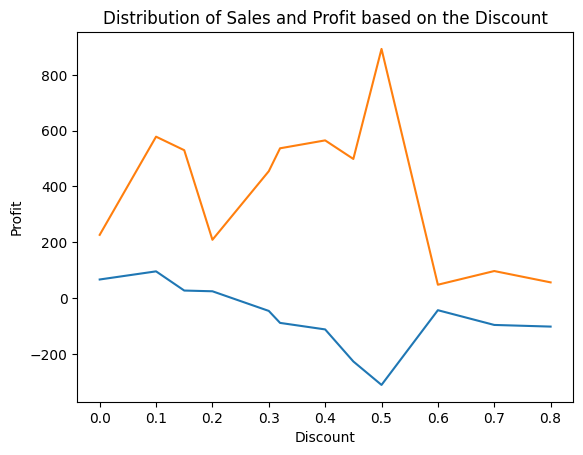

In [49]:
# disturbution of sales and profit based on the discount 
sns.lineplot(df.groupby('Discount')[['Sales', 'Profit']].mean().reset_index(), x='Discount', y='Profit')
sns.lineplot(df.groupby('Discount')[['Sales', 'Profit']].mean().reset_index(), x='Discount', y='Sales')
plt.title('Distribution of Sales and Profit based on the Discount')

Text(0.5, 1.0, 'Disturbution of Sales based on the Discount')

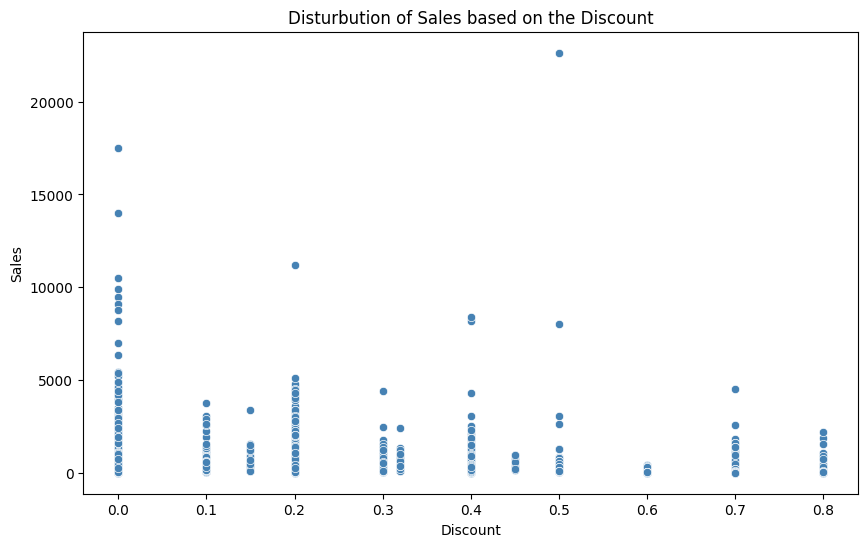

In [ ]:

plt.figure(figsize=[10,6])
sns.scatterplot(x='Discount', y='Sales', data=df, color='steelblue')
plt.title('Disturbution of Sales based on the Discount')

Text(0.5, 1.0, 'Disturbution of Profit based on the Discount')

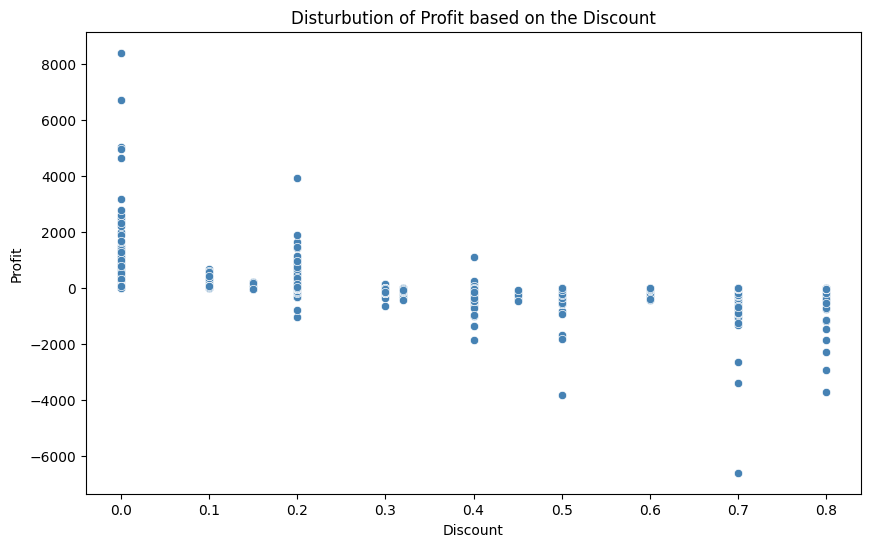

In [39]:
plt.figure(figsize=[10,6])
sns.scatterplot(x='Discount', y='Profit', data=df, color='steelblue')
plt.title('Disturbution of Profit based on the Discount')

<Axes: ylabel='Sales'>

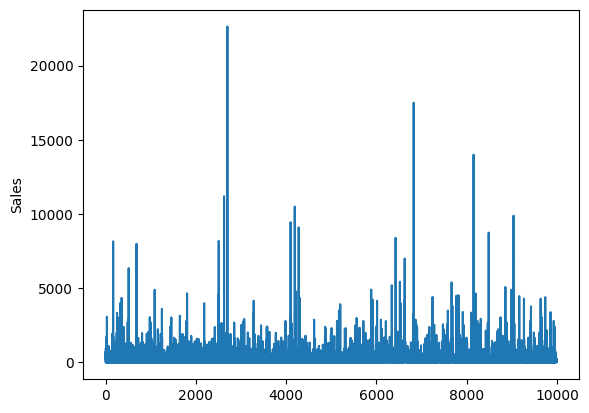

In [52]:
# PLOT THE SALES 
sns.lineplot(df['Sales'])

In [53]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [91]:
df.groupby('Ship Mode')[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending=False)

,Sales,Profit
Ship Mode,,
First Class,228.497024,31.839948
Second Class,236.089239,29.535545
Same Day,236.396179,29.266591
Standard Class,227.583067,27.494770


In [55]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [58]:
# let's find out why the first class has the highest profit
df.groupby('Ship Mode')['Discount'].mean()

Ship Mode
First Class       0.164610
Same Day          0.152394
Second Class      0.138895
Standard Class    0.160023
Name: Discount, dtype: float64

In [71]:
df.groupby(['Ship Mode', 'Category'])[['Profit','Sales']].mean()

Profit       Sales
Ship Mode      Category                              
First Class    Furniture         9.379044  338.625452
               Office Supplies  20.220142  111.354186
               Technology       91.370643  463.008608
Same Day       Furniture         6.700407  328.981336
               Office Supplies  19.704047   89.234604
               Technology       88.478483  613.508827
Second Class   Furniture         9.897568  366.016451
               Office Supplies  23.496673  139.481773
               Technology       71.454116  388.583448
Standard Class Furniture         8.301855  349.223933
               Office Supplies  19.405933  117.630907
               Technology       76.829286  456.971382

In [69]:
# check which category or sub-category has the highest sales and profit
df.groupby('Category')[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending=False)

,Sales,Profit
Category,,
Technology,452.709276,78.752002
Office Supplies,119.324101,20.327050
Furniture,349.834887,8.699327


In [78]:
df.groupby('Ship Mode')['Quantity'].mean().sort_values(ascending=False)

Ship Mode
Standard Class    3.819873
Second Class      3.816452
First Class       3.701560
Same Day          3.609576
Name: Quantity, dtype: float64

In [79]:
df.groupby('Ship Mode')['Category'].value_counts()

Ship Mode       Category       
First Class     Office Supplies     910
                Furniture           327
                Technology          301
Same Day        Office Supplies     326
                Furniture           119
                Technology           98
Second Class    Office Supplies    1152
                Furniture           427
                Technology          366
Standard Class  Office Supplies    3638
                Furniture          1248
                Technology         1082
Name: count, dtype: int64

In [80]:
df.groupby('Sub-Category')[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending=False)

,Sales,Profit
Sub-Category,,
Copiers,2198.941618,817.909190
Accessories,215.974604,54.111788
Phones,371.211534,50.073938
Chairs,532.332420,43.095894
Appliances,230.755710,38.922758
Machines,1645.553313,29.432669
Envelopes,64.867724,27.418019
Storage,264.590553,25.152277
Paper,57.284092,24.856620


In [85]:
df[df['Category']=='Technology'].groupby(['Sub-Category', 'Ship Mode'])[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending=False)

Sales       Profit
Sub-Category Ship Mode                               
Copiers      First Class     3280.802500  1233.198275
             Standard Class  2324.969556   870.961678
             Same Day        1511.973600   516.190980
             Second Class    1259.975200   458.924687
Machines     Second Class    1606.692857   154.073564
Accessories  Same Day         336.029854    94.309537
Phones       First Class      388.520783    60.871522
Accessories  Second Class     231.932012    53.911548
             Standard Class   211.268955    52.767705
Phones       Standard Class   369.190491    48.601780
             Second Class     361.458446    47.872202
Accessories  First Class      173.646031    46.151665
Machines     Same Day        2279.853700    43.877080
Phones       Same Day         380.672286    42.487490
Machines     Standard Class  1761.661662    35.183165
             First Class     1050.147870   -69.717348

In [89]:
df.groupby(['Ship Mode', 'Sub-Category'])['Profit'].sum().sort_values(ascending=False)

Ship Mode       Sub-Category
Standard Class  Copiers         31354.6204
                Phones          25953.3506
                Accessories     23428.8608
                Binders         19491.9967
                Paper           19478.8185
                                   ...    
First Class     Tables          -1365.3665
                Machines        -1603.4990
Standard Class  Bookcases       -2531.1028
Second Class    Tables          -3320.6799
Standard Class  Tables         -11910.0122
Name: Profit, Length: 68, dtype: float64

In [92]:
df.groupby('Segment')[['Sales', 'Profit']].mean().sort_values(by='Profit', ascending=False)

,Sales,Profit
Segment,,
Home Office,240.972041,33.818664
Corporate,233.823300,30.456667
Consumer,223.733644,25.836873


In [104]:
df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [98]:
df.groupby('State')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Washington,138641.2700,33402.6517
Michigan,76269.6140,24463.1876
Virginia,70636.7200,18597.9504
Indiana,53555.3600,18382.9363
Georgia,49095.8400,16250.0433
Kentucky,36591.7500,11199.6966
Minnesota,29863.1500,10823.1874


In [97]:
df.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
City,,
New York City,256368.1610,62036.9837
Los Angeles,175851.3410,30440.7579
Seattle,119540.7420,29156.0967
San Francisco,112669.0920,17507.3854
Detroit,42446.9440,13181.7908
...,...,...
Chicago,48539.5410,-6654.5688
Lancaster,9891.4640,-7239.0684
San Antonio,21843.5280,-7299.0502


In [101]:
df.groupby('City').size().sort_values(ascending=False).head(10)

City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Seattle          428
Houston          377
Chicago          314
Columbus         222
San Diego        170
Springfield      163
dtype: int64

In [102]:
df.groupby('State').size().sort_values(ascending=False).head(10)

State
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michigan           255
North Carolina     249
dtype: int64

In [105]:
df[df['State']=='Texas'].groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
Sub-Category,,
Phones,28589.5680,3222.4608
Paper,6983.4560,2422.9703
Copiers,5639.8720,1629.9615
Accessories,11328.5600,1105.8501
Envelopes,2530.6480,848.1760
Art,2369.5280,316.3538
Labels,583.6000,200.4020
Fasteners,332.4640,80.7357
Storage,15723.5840,-763.7054


In [106]:
# find the product name with the highest profit 
df.groupby('Product Name')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766
...,...,...
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904


In [107]:
df.groupby('Customer Name')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
Customer Name,,
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Adrian Barton,14473.571,5444.8055
...,...,...
Henry Goldwyn,3247.642,-2797.9635
Sharelle Roach,3233.481,-3333.9144
Luke Foster,3930.509,-3583.9770


Text(0.5, 1.0, 'Top 10 Customers by Profit')

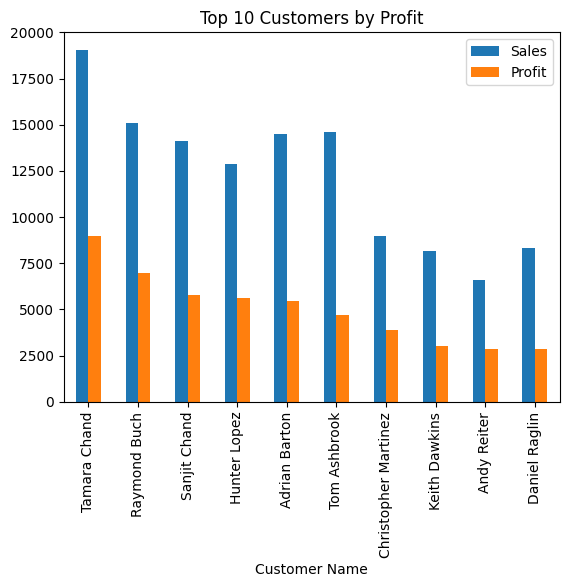

In [114]:
top_customers = df.groupby('Customer Name')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Customers by Profit')

In [109]:
worst=df[df['Customer Name']== 'Sean Miller']
worst[['Sales', 'Profit','Discount', 'Category','Sub-Category', 'City']].describe(include='all')

,Sales,Profit,Discount,Category,Sub-Category,City
count,15.000000,15.000000,15.000000,15,15,15
unique,NaN,NaN,NaN,3,9,5
top,NaN,NaN,NaN,Office Supplies,Paper,Jacksonville
freq,NaN,NaN,NaN,9,4,7
mean,1669.536667,-132.049287,0.246667,NaN,NaN,NaN
std,5807.087126,467.115828,0.184649,NaN,NaN,NaN
min,3.488000,-1811.078400,0.000000,NaN,NaN,NaN
25%,14.448000,-8.561800,0.200000,NaN,NaN,NaN
50%,30.768000,3.802400,0.200000,NaN,NaN,NaN
75%,324.401000,7.779100,0.200000,NaN,NaN,NaN


In [111]:
worst.sort_values(by='Profit', ascending=False)[['Product Name', 'Discount', 'Sales', 'Profit', 'Ship Mode', 'Category', 'Sub-Category']]

,Product Name,Discount,Sales,Profit,Ship Mode,Category,Sub-Category
2573,Eldon Antistatic Chair Mats for Low to Medium ...,0.0,526.450,31.5870,Standard Class,Furniture,Furnishings
9191,Xerox 1979,0.2,49.568,15.4900,Standard Class,Office Supplies,Paper
2702,"Dana Fluorescent Magnifying Lamp, White, 36""",0.2,122.352,15.2940,Standard Class,Furniture,Furnishings
2700,"Executive Impressions 13"" Clairmont Wall Clock",0.2,30.768,8.0766,Standard Class,Furniture,Furnishings
2698,Xerox 195,0.2,21.376,7.4816,Standard Class,Office Supplies,Paper
2701,Staples,0.2,18.936,5.9175,Standard Class,Office Supplies,Fasteners
7853,Xerox 1949,0.0,9.960,4.8804,Standard Class,Office Supplies,Paper
9188,Sabrent 4-Port USB 2.0 Hub,0.2,21.728,3.8024,Standard Class,Technology,Accessories
2266,Xerox 1989,0.2,7.968,2.6892,Same Day,Office Supplies,Paper
2699,Avery Fluorescent Highlighter Four-Color Set,0.2,8.016,1.0020,Standard Class,Office Supplies,Art


<Axes: >

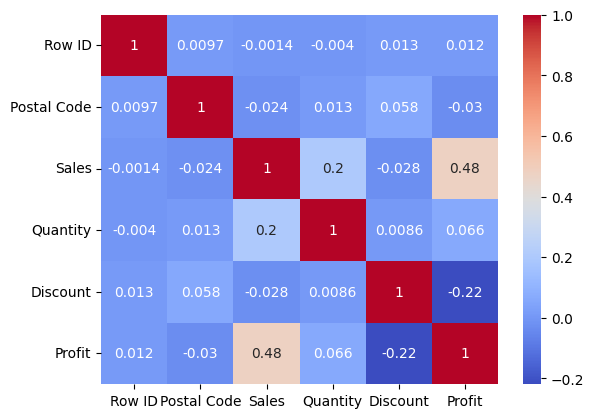

In [119]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')